In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [2]:
df = pd.read_csv("08-seismic_activity_svm.csv")

In [3]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [5]:
df["seismic_event_detected"].unique()

array([0, 1])

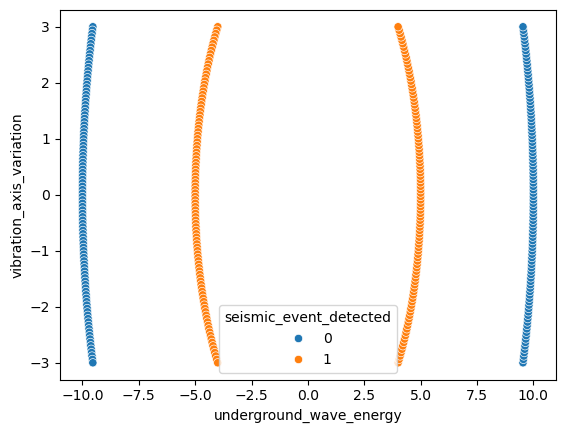

In [6]:
sns.scatterplot(data = df, x = "underground_wave_energy", y = "vibration_axis_variation", hue = "seismic_event_detected")
plt.show()

In [7]:
X = df[["underground_wave_energy", "vibration_axis_variation"]].values
y = df["seismic_event_detected"].values

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [10]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)

y_train = torch.tensor(y_train, dtype = torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype = torch.float32).unsqueeze(1)

In [11]:
y_train.ndim

2

In [12]:
from torch import nn

In [13]:
class LinearClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(in_features=2, out_features=5)
        self.layer2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x):
        return self.layer2(self.layer1(x))
        

In [14]:
linear_model = LinearClassificationModel()

In [15]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = linear_model.parameters(), lr = 0.01)

In [16]:
def calculate_acc (y_test, y_pred):
    correct = torch.eq(y_test, y_pred).sum().item()
    accuracy = (correct / len(y_test)) * 100
    return accuracy

In [17]:
torch.manual_seed(42)
epochs = 120

for epoch in range(epochs):
    linear_model.train()
    y_logits = linear_model(X_train)
    y_preds = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = calculate_acc(y_train, y_preds)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    linear_model.eval()
    with torch.inference_mode():
        test_logits = linear_model(X_test)
        test_preds = torch.round(torch.sigmoid(X_test))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_acc(y_test, test_preds)

        if (epoch % 5 == 0):
            print(f"Epoch: {epoch}, Train Loss: {loss}, Train Accuracy: {acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}")

Epoch: 0, Train Loss: 1.2432931661605835, Train Accuracy: 48.75, Test Loss: 1.0152027606964111, Test Accuracy: 88.75
Epoch: 5, Train Loss: 0.9099805951118469, Train Accuracy: 48.75, Test Loss: 0.7739211916923523, Test Accuracy: 88.75
Epoch: 10, Train Loss: 0.744663417339325, Train Accuracy: 48.75, Test Loss: 0.6868498921394348, Test Accuracy: 88.75
Epoch: 15, Train Loss: 0.6963327527046204, Train Accuracy: 54.6875, Test Loss: 0.6919772028923035, Test Accuracy: 88.75
Epoch: 20, Train Loss: 0.6963688731193542, Train Accuracy: 52.1875, Test Loss: 0.7203329205513, Test Accuracy: 88.75
Epoch: 25, Train Loss: 0.7025949954986572, Train Accuracy: 51.24999999999999, Test Loss: 0.7356523275375366, Test Accuracy: 88.75
Epoch: 30, Train Loss: 0.7017647624015808, Train Accuracy: 51.24999999999999, Test Loss: 0.7340048551559448, Test Accuracy: 88.75
Epoch: 35, Train Loss: 0.6968544125556946, Train Accuracy: 51.24999999999999, Test Loss: 0.7245818376541138, Test Accuracy: 88.75
Epoch: 40, Train Loss:

In [18]:
# let's try with another activation function

class NewLinearClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(in_features=2, out_features=5)
        self.layer2 = nn.Linear(in_features=5, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer2(self.relu(self.layer1(x)))
        

In [19]:
new_linear_model = NewLinearClassificationModel()

In [20]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = new_linear_model.parameters(), lr = 0.01)

In [21]:
torch.manual_seed(42)
epochs = 120

for epoch in range(epochs):
    new_linear_model.train()
    y_logits = new_linear_model(X_train)
    y_preds = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = calculate_acc(y_train, y_preds)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    new_linear_model.eval()
    with torch.inference_mode():
        test_logits = new_linear_model(X_test)
        test_preds = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_acc(y_test, test_preds)

        if (epoch % 5 == 0):
            print(f"Epoch: {epoch}, Train Loss: {loss}, Train Accuracy: {acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}")

Epoch: 0, Train Loss: 0.6991726756095886, Train Accuracy: 48.75, Test Loss: 0.7071055173873901, Test Accuracy: 50.0
Epoch: 5, Train Loss: 0.6477659940719604, Train Accuracy: 50.0, Test Loss: 0.6305733919143677, Test Accuracy: 55.00000000000001
Epoch: 10, Train Loss: 0.6237033009529114, Train Accuracy: 52.81249999999999, Test Loss: 0.6001629829406738, Test Accuracy: 56.25
Epoch: 15, Train Loss: 0.601661205291748, Train Accuracy: 59.06249999999999, Test Loss: 0.5860621333122253, Test Accuracy: 58.75
Epoch: 20, Train Loss: 0.5799291133880615, Train Accuracy: 64.0625, Test Loss: 0.5764077305793762, Test Accuracy: 63.74999999999999
Epoch: 25, Train Loss: 0.558687686920166, Train Accuracy: 65.3125, Test Loss: 0.5574032068252563, Test Accuracy: 67.5
Epoch: 30, Train Loss: 0.5342087745666504, Train Accuracy: 68.4375, Test Loss: 0.5276044607162476, Test Accuracy: 67.5
Epoch: 35, Train Loss: 0.5068351626396179, Train Accuracy: 71.875, Test Loss: 0.49562034010887146, Test Accuracy: 72.5
Epoch: 40